In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Monthly online RMSE visualization

In this notebook, we evaluate the online monthly RMSE of temperature, moisture, zonal wind, and tota cloud. We provide the exactly code to reproduce the Figure 2 in "Stable Machine-Learning Parameterization of Subgrid Processes with Real Geography and Full-physics Emulation", Hu et al. 2024, arXiv preprint:2306.08754.

## Set data path

All the simulation output, saved model weights, and preprocessed data used in Hu et al. 2024 "Stable Machine-Learning Parameterization of Subgrid Processes with Real Geography and Full-physics Emulation" are provided in a hu_etal2024_data folder that you can download. Please change the following path to your downloaded hu_etal2024_data folder.

In [7]:
#data_path = '/global/homes/z/zeyuanhu/scratch/hu_etal2024_data/'
#data_path = '/media/peter/CrucialBX500/data/ClimSim/hu_etal2024_data/'

data_path = '/data/ClimSim/hu_etal2024_data/'
data_path_docker = "/data/climsim-online/scratch/"

In [8]:
# open the one-year reference mmf simulation
ds_sp = xr.open_dataset(data_path + 'h0/1year/mmf_ref/mmf_ref.eam.h0.0003.nc')

In [9]:
ps_sp = ds_sp.PS
p_interface = ds_sp.hyai*ds_sp.P0 + ds_sp.hybi*ds_sp.PS
p_interface = p_interface.values
p_interface = np.transpose(p_interface, (1,0,2))
dp = p_interface[:,1:61,:] - p_interface[:,0:60,:]
area = ds_sp.area
area_weight = area.values[np.newaxis,np.newaxis,:]
total_weight = dp*area_weight
total_weight.shape

# Function to calculate RMSE per month for total cloud mixing ratio (liquid + ice)
def calculate_rmse_qn(ds1, ds2, total_weight):
    # Determine the number of months in ds1
    num_months = ds1['CLDLIQ'].shape[0]
    
    # Slice total_weight to match the number of months in ds1
    total_weight_sliced = total_weight[:num_months, :, :]
    
    # Initialize the RMSE array with NaN values
    rmse_per_month = np.full(12, np.nan)
    
    # Compute RMSE for existing months
    squared_diff = (ds1['CLDLIQ'] - ds2['CLDLIQ'] + ds1['CLDICE'] - ds2['CLDICE']) ** 2
    weighted_squared_diff = squared_diff * total_weight_sliced
    weighted_sum = weighted_squared_diff.sum(axis=(1, 2))
    total_weight_sum = total_weight_sliced.sum(axis=(1, 2))
    weighted_mean_squared_diff = weighted_sum / total_weight_sum
    rmse_existing_months = np.sqrt(weighted_mean_squared_diff)
    
    # Fill in the RMSE array with the computed values
    rmse_per_month[:num_months] = rmse_existing_months.values
    
    return rmse_per_month

# Function to calculate RMSE per month for other variables (T, Q, U)
def calculate_rmse(ds1, ds2, total_weight,var='T'):
    # Determine the number of months in ds1
    num_months = ds1[var].shape[0]
    
    # Slice total_weight to match the number of months in ds1
    total_weight_sliced = total_weight[:num_months, :, :]
    
    # Initialize the RMSE array with NaN values
    rmse_per_month = np.full(12, np.nan)
    
    # Compute RMSE for existing months
    squared_diff = (ds1[var] - ds2[var]) ** 2
    weighted_squared_diff = squared_diff * total_weight_sliced
    weighted_sum = weighted_squared_diff.sum(axis=(1, 2))
    total_weight_sum = total_weight_sliced.sum(axis=(1, 2))
    weighted_mean_squared_diff = weighted_sum / total_weight_sum
    rmse_existing_months = np.sqrt(weighted_mean_squared_diff)
    
    # Fill in the RMSE array with the computed values
    rmse_per_month[:num_months] = rmse_existing_months.values
    
    return rmse_per_month

In [10]:
# Load the three other mmf simulations that share the same initial condition of the reference mmf run but diverge due to random numerical round off error due to GPU calculation. 
ds_sp_re = xr.open_dataset(data_path + 'h0/1year/mmf_a/mmf_a.eam.h0.0003.nc')
ds_sp_re_b = xr.open_dataset(data_path + 'h0/1year/mmf_b/mmf_b.eam.h0.0003.nc')
ds_sp_re_c = xr.open_dataset(data_path + 'h0/1year/mmf_c/mmf_c.eam.h0.0003.nc')

# NN case groups
case_groups = [
    [
        'unet_v5/huber_rop',
        'unet_v5/huber_step',
        'unet_v5/mae_step'
    ],
    [
        'ckpt_ftorch_cpu2_pure_resLSTM_v6_1024_epoch_12_metric_0.0513'
    ],
   # physRNN 
    [
    # detRNN predict fluxes + sourcesink(->precip) enforce q positivity 
        #'27072', # "lossw_loss=h,rh_mp-2_addq_sedm_enforceposqtot_NOevapprec_TENDFIX_LSTM144_prevt_CONDMLPlfrac ep7?
        '5315', # fallspeed=mlp*g*0.4*qi**1.5_clampfixes
       # # '20905_ep54',# lossw_loss=h,rh,cldpath_mp-2_addq_sedm_enforceposqtot_NOevapprec_TENDFIX_LSTM144_prevt_CONDMLPlfrac   ep54
         '91502', # meancrmatend_aaqn**w_Poldevap_qnmax_PmaxfromT_lossw_loss=h,rh,cldpath,negprec,accumprec1.5e14_mp-1_addq_sedm_condheat_storeprec2e4-evappour-enforceposqvqn_GRU160_NOprevt
         '63016' # # meancrmatend_aaqn**2_Poldevap_qnmax_PmaxfromT_lossw_loss=h,rh,cldpath,negprec,accumprec1.5e14_mp-1_addq_sedm_condheat_storeprec2e4-evappour-enforceposqvqn_GRU160_NOprevt
    ],
    # PhysRNN + physRad
    [
     #'24508',
     '32534',
    # '22362',
     '53373_ep46',
     '41075'
    ]

]


T
unet_v5/huber_rop
casename unet_v5/huber_rop label U-net, mem=y (Han et al. 2025) RMSE 1.9011239399499444
unet_v5/huber_step
casename unet_v5/huber_step label None RMSE 1.9151083028925215
unet_v5/mae_step
casename unet_v5/mae_step label None RMSE 1.985252093571069
ckpt_ftorch_cpu2_pure_resLSTM_v6_1024_epoch_12_metric_0.0513
casename ckpt_ftorch_cpu2_pure_resLSTM_v6_1024_epoch_12_metric_0.0513 label ResLSTM, mem=y  (Lin et al. 2026) RMSE 7.1266025881474135
5315
casename 5315 label RNN, mem=y+h, conservation equations RMSE 3.9972561259120707
91502
casename 91502 label None RMSE 2.379803498329918
63016
casename 63016 label None RMSE 2.7669242049491527
32534
casename 32534 label RNN, mem=y+h, conservation equations + physical rad. RMSE 2.2484221782251
53373_ep46
casename 53373_ep46 label None RMSE 2.3970276943991577
41075
casename 41075 label None RMSE 1.9611481530224681
Q
casename unet_v5/huber_rop label None RMSE 0.5996075560748279
casename unet_v5/huber_step label None RMSE 0.54518552

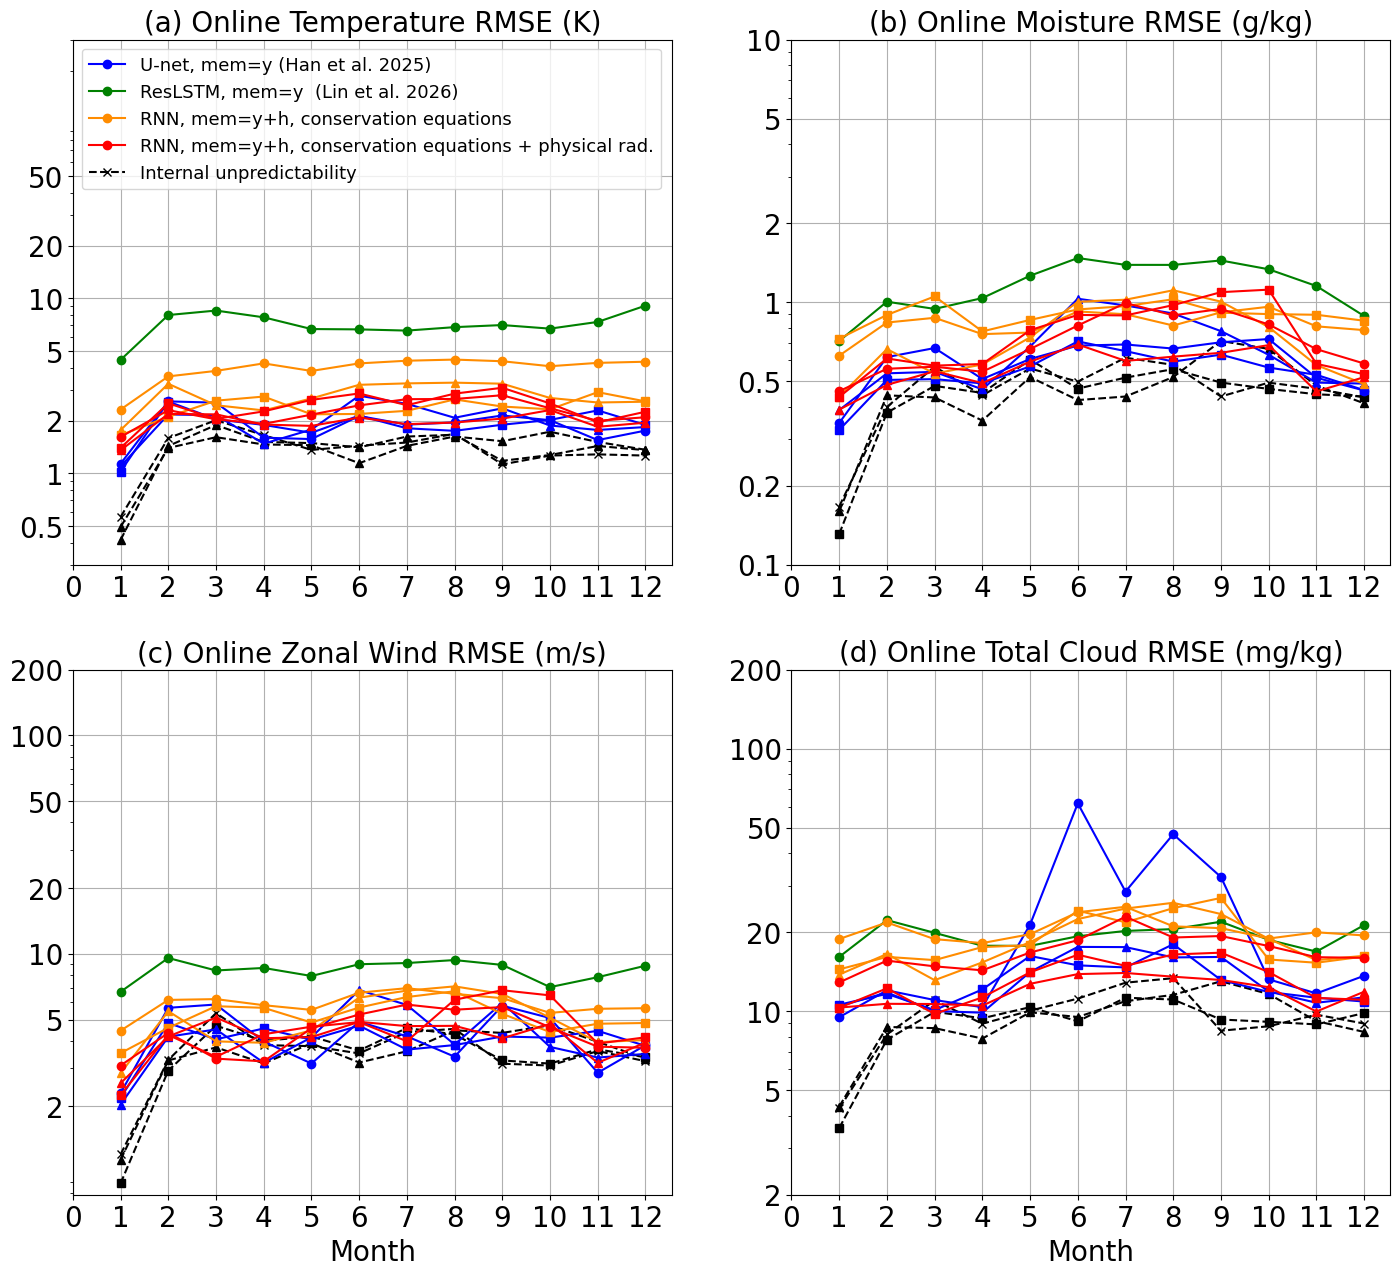

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray as xr

xr.set_options(use_new_combine_kwarg_defaults=True)

fs_label = 13 # 12

fig, axs = plt.subplots(2, 2, figsize=(17, 15))

fig.subplots_adjust(hspace=0.2, wspace=0.2)

labels =  [
           'U-net, mem=y (Han et al. 2025)', 
           'ResLSTM, mem=y  (Lin et al. 2026)',
           'RNN, mem=y+h, conservation equations',
           'RNN, mem=y+h, conservation equations + physical rad.' ]
  #         'StochasticGRU, mem=h, physics informed']

desired_order = labels.copy()
desired_order.append('Internal unpredictability')
           
ax = axs[0, 0]
colors = ['cyan', 'blue', 'green', 'darkorange', 'red']
#colors = ['cyan', 'blue', 'green', 'darkorange', 'black', 'red']
colors = ['green', 'blue', 'darkorange', 'red']


markers = ['o', 's', '^', 'D', '*']
markers = ['o', 's', '^', 'D']
var = 'T'
lines_labels = {}

rmse_per_month_sp_re = calculate_rmse(ds_sp_re, ds_sp, total_weight, var)
line, = ax.plot(np.arange(1, 13), rmse_per_month_sp_re, label='Internal unpredictability', color='black', linestyle='--', marker='x')
lines_labels['Internal unpredictability'] = line

rmse_per_month_sp_re_b = calculate_rmse(ds_sp_re_b, ds_sp, total_weight, var)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_b, label='', color='black', linestyle='--', marker='^')
rmse_per_month_sp_re_c = calculate_rmse(ds_sp_re_c, ds_sp, total_weight, var)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_c, label='', color='black', linestyle='--', marker='^')

print(var)
for group_idx, group in enumerate(case_groups):
    for case_idx, casename in enumerate(group):
        print(casename)
        if "unet" in casename:
            ds_nn = xr.open_mfdataset(data_path + f'h0/1year/{casename}/*.eam.h0.0003-*.nc')
        elif "ckpt" in casename:
            ds_nn = xr.open_mfdataset(data_path_docker + f'{casename}/run/*.eam.h0.0003-*.nc')
        else:
            ds_nn = xr.open_mfdataset(data_path_docker + f'example_job_submit_nnwrapper_v4_rnn_{casename}/run/*.eam.h0.0003-*.nc')
        rmse_per_month_nn = calculate_rmse(ds_nn, ds_sp, total_weight, var)
        months = np.arange(1, 13)
        label = None
        if case_idx == 0:
            label = labels[group_idx]
        line, = ax.plot(months, rmse_per_month_nn, label=label, color=colors[group_idx], marker=markers[case_idx])
        if label:
            lines_labels[label] = line
        print("casename", casename, "label", label, "RMSE", np.mean(rmse_per_month_nn))

ax.set_yscale('log')
ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50])
ax.set_yticklabels(['0.5', '1', '2', '5', '10', '20', '50'], fontsize=20)
#ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.set_title('(a) Online Temperature RMSE (K)', fontsize=20)
#desired_order = ['MLP', 'Unet + expanded inputs', 'Unet + expanded inputs + microphysical constraints', 'Internal unpredictability']
ax.legend([lines_labels[label] for label in desired_order], desired_order, fontsize=fs_label, loc='upper left')
ax.grid(True)
ax.set_xticks([0] + list(np.arange(1, 13)))
ax.set_xticklabels([0] + list(np.arange(1, 13)), fontsize=20)
ax.set_ylim(0.3, 300)

# Second row right panel (lower right)
ax = axs[0, 1]
var = 'Q'
rmse_per_month_sp_re = calculate_rmse(ds_sp_re, ds_sp, total_weight, var) * 1e3
ax.plot(np.arange(1, 13), rmse_per_month_sp_re, label='Internal unpredictability', color='black', linestyle='--', marker='x')
rmse_per_month_sp_re_b = calculate_rmse(ds_sp_re_b, ds_sp, total_weight, var) * 1e3
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_b, label='', color='black', linestyle='--', marker='^')
rmse_per_month_sp_re_c = calculate_rmse(ds_sp_re_c, ds_sp, total_weight, var) * 1e3
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_c, label='', color='black', linestyle='--', marker='s')

print(var)
for group_idx, group in enumerate(case_groups):
    for case_idx, casename in enumerate(group):
        #print(casename)
        if "unet" in casename:
            ds_nn = xr.open_mfdataset(data_path + f'h0/1year/{casename}/*.eam.h0.0003-*.nc')
        elif "ckpt" in casename:
            ds_nn = xr.open_mfdataset(data_path_docker + f'{casename}/run/*.eam.h0.0003-*.nc')
        else:
            ds_nn = xr.open_mfdataset(data_path_docker + f'example_job_submit_nnwrapper_v4_rnn_{casename}/run/*.eam.h0.0003-*.nc')
        rmse_per_month_nn = calculate_rmse(ds_nn, ds_sp, total_weight, var) * 1e3
        print("casename", casename, "label", label, "RMSE", np.mean(rmse_per_month_nn))
        if case_idx == 0:
            label = labels[group_idx]
        ax.plot(np.arange(1, 13), rmse_per_month_nn, label=label, color=colors[group_idx], marker=markers[case_idx])
        label = None

ax.set_yscale('log')
ax.set_yticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
ax.set_yticklabels(['0.1', '0.2', '0.5', '1', '2', '5', '10'], fontsize=20)
#ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.set_title('(b) Online Moisture RMSE (g/kg)', fontsize=20)
ax.grid(True)
ax.set_xticks([0] + list(np.arange(1, 13)))
ax.set_xticklabels([0] + list(np.arange(1, 13)), fontsize=20)


# Third row left panel (lower left)
ax = axs[1, 0]
var = 'U'
rmse_per_month_sp_re = calculate_rmse(ds_sp_re, ds_sp, total_weight, var) 
ax.plot(np.arange(1, 13), rmse_per_month_sp_re, label='Internal unpredictability', color='black', linestyle='--', marker='x')
rmse_per_month_sp_re_b = calculate_rmse(ds_sp_re_b, ds_sp, total_weight, var)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_b, label='', color='black', linestyle='--', marker='^')
rmse_per_month_sp_re_c = calculate_rmse(ds_sp_re_c, ds_sp, total_weight, var)
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_c, label='', color='black', linestyle='--', marker='s')

print(var)
for group_idx, group in enumerate(case_groups):
    for case_idx, casename in enumerate(group):
        #print(casename)
        if "unet" in casename:
            ds_nn = xr.open_mfdataset(data_path + f'h0/1year/{casename}/*.eam.h0.0003-*.nc')
        elif "ckpt" in casename:
            ds_nn = xr.open_mfdataset(data_path_docker + f'{casename}/run/*.eam.h0.0003-*.nc')
        else:
            ds_nn = xr.open_mfdataset(data_path_docker + f'example_job_submit_nnwrapper_v4_rnn_{casename}/run/*.eam.h0.0003-*.nc')
        rmse_per_month_nn = calculate_rmse(ds_nn, ds_sp, total_weight, var) 
        print("casename", casename, "label", label, "RMSE", np.mean(rmse_per_month_nn))
        months = np.arange(1, 13)
        label = None
        if case_idx == 0:
            label = labels[group_idx]
        ax.plot(months, rmse_per_month_nn, label=label, color=colors[group_idx], marker=markers[case_idx])

ax.set_yscale('log')
#ax.set_yticks([0.5, 1, 2, 5, 10, 20, 50, 100])
#ax.set_yticklabels(['0.5', '1', '2', '5', '10', '20', '50', '100'], fontsize=20)
yticks=[2, 5, 10, 20, 50, 100, 200]
ax.set_yticks(yticks)
ax.set_yticklabels([str(x) for x in yticks], fontsize=20)
ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.set_title('(c) Online Zonal Wind RMSE (m/s)', fontsize=20)
ax.grid(True)
ax.set_xticks([0] + list(np.arange(1, 13)))
ax.set_xticklabels([0] + list(np.arange(1, 13)), fontsize=20)

# Third row right panel (lower right) total cloud
ax = axs[1, 1]
rmse_per_month_sp_re = calculate_rmse_qn(ds_sp_re, ds_sp, total_weight) * 1e6
ax.plot(np.arange(1, 13), rmse_per_month_sp_re, label='Internal unpredictability', color='black', linestyle='--', marker='x')
rmse_per_month_sp_re_b = calculate_rmse_qn(ds_sp_re_b, ds_sp, total_weight) * 1e6
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_b, label='', color='black', linestyle='--', marker='^')
rmse_per_month_sp_re_c = calculate_rmse_qn(ds_sp_re_c, ds_sp, total_weight) * 1e6
ax.plot(np.arange(1, 13), rmse_per_month_sp_re_c, label='', color='black', linestyle='--', marker='s')

for group_idx, group in enumerate(case_groups):
    for case_idx, casename in enumerate(group):
        if "unet" in casename:
            ds_nn = xr.open_mfdataset(data_path + f'h0/1year/{casename}/*.eam.h0.0003-*.nc')
        elif "ckpt" in casename:
            ds_nn = xr.open_mfdataset(data_path_docker + f'{casename}/run/*.eam.h0.0003-*.nc')
        else:
            ds_nn = xr.open_mfdataset(data_path_docker + f'example_job_submit_nnwrapper_v4_rnn_{casename}/run/*.eam.h0.0003-*.nc')
        rmse_per_month_nn = calculate_rmse_qn(ds_nn, ds_sp, total_weight) * 1e6
        label = None
        if case_idx == 0:
            label = labels[group_idx]
        ax.plot(np.arange(1, 13), rmse_per_month_nn, label=label, color=colors[group_idx], marker=markers[case_idx])
        print("casename", casename, "label", label, "RMSE", np.mean(rmse_per_month_nn))

ax.set_yscale('log')
#ax.set_yticks([2, 5, 10, 20, 50, 100, 200, 500])
#ax.set_yticklabels(['2', '5', '10', '20', '50', '100', '200', '500'], fontsize=20)
yticks=[2, 5, 10, 20, 50, 100, 200]
ax.set_yticks(yticks)
ax.set_yticklabels([str(x) for x in yticks], fontsize=20)
ax.set_xlabel('Month', fontsize=20)
ax.set_ylabel('', fontsize=20)
ax.set_title('(d) Online Total Cloud RMSE (mg/kg)', fontsize=20)
ax.grid(True)
ax.set_xticks([0] + list(np.arange(1, 13)))
ax.set_xticklabels([0] + list(np.arange(1, 13)), fontsize=20)
# plt.savefig('james_ablation_offline_online_reorder_warrow.pdf', format='pdf', dpi=300, bbox_inches='tight')
# Show the plot
#plt.savefig('EGU_RNN_online.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()